In [20]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.preprocessing import MinMaxScaler

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, LSTM, Dropout

In [21]:
dataset_train = pd.read_csv('google.csv')

In [22]:
dataset_train

,Date,Open,High,Low,Close,Volume
0,1/3/2012,325.25,332.83,324.97,663.59,"7,380,500"
1,1/4/2012,331.27,333.87,329.08,666.45,"5,749,400"
2,1/5/2012,329.83,330.75,326.89,657.21,"6,590,300"
3,1/6/2012,328.34,328.77,323.68,648.24,"5,405,900"
4,1/9/2012,322.04,322.29,309.46,620.76,"11,688,800"
...,...,...,...,...,...,...
1253,12/23/2016,790.90,792.74,787.28,789.91,"623,400"
1254,12/27/2016,790.68,797.86,787.66,791.55,"789,100"
1255,12/28/2016,793.70,794.23,783.20,785.05,"1,153,800"
1256,12/29/2016,783.33,785.93,778.92,782.79,"744,300"


In [23]:
training_set = dataset_train.iloc[:, 1:2].values

In [24]:
scaler = MinMaxScaler(feature_range=(0,1))

training_set_scaled = scaler.fit_transform(training_set)

In [25]:
X_train = []
y_train = []

for i in range(60, len(training_set_scaled)):
  X_train.append(
      training_set_scaled[i-60:i,0]
  )

  y_train.append(
      training_set_scaled[i,0]
  )

X_train, y_train = np.array(X_train), np.array(y_train)

In [26]:
X_train = np.reshape(
    X_train,
    (X_train.shape[0],
     X_train.shape[1],
     1)
)

In [27]:
model = Sequential()

model.add(
    LSTM(
        units=50,
        return_sequences=True
    )
)

In [28]:
model.add(Dropout(0.2))

In [29]:
model.add(LSTM(
    units=50,
    return_sequences=True
))


In [30]:
model.add(Dropout(0.2))

In [31]:
model.add(LSTM(
    units=50,
    return_sequences=True
))

In [32]:
model.add(Dropout(0.2))

In [33]:
model.add(LSTM(
    units=50
))

In [34]:
model.add(Dropout(0.2))

In [35]:
model.add(Dense(units=1))

In [36]:
model.compile(
    optimizer='adam',
    loss='mean_squared_error'
)


In [37]:
history = model.fit(
    X_train,
    y_train,
    epochs=20,
    batch_size=32
)

Epoch 1/20
38/38 ━━━━━━━━━━━━━━━━━━━━ 11s 104ms/step - loss: 0.0513
Epoch 2/20
38/38 ━━━━━━━━━━━━━━━━━━━━ 6s 120ms/step - loss: 0.0067
Epoch 3/20
38/38 ━━━━━━━━━━━━━━━━━━━━ 5s 113ms/step - loss: 0.0055
Epoch 4/20
38/38 ━━━━━━━━━━━━━━━━━━━━ 4s 106ms/step - loss: 0.0057
Epoch 5/20
38/38 ━━━━━━━━━━━━━━━━━━━━ 6s 142ms/step - loss: 0.0054
Epoch 6/20
38/38 ━━━━━━━━━━━━━━━━━━━━ 10s 126ms/step - loss: 0.0046
Epoch 7/20
38/38 ━━━━━━━━━━━━━━━━━━━━ 5s 142ms/step - loss: 0.0046
Epoch 8/20
38/38 ━━━━━━━━━━━━━━━━━━━━ 4s 105ms/step - loss: 0.0046
Epoch 9/20
38/38 ━━━━━━━━━━━━━━━━━━━━ 6s 136ms/step - loss: 0.0043
Epoch 10/20
38/38 ━━━━━━━━━━━━━━━━━━━━ 4s 107ms/step - loss: 0.0046
Epoch 11/20
38/38 ━━━━━━━━━━━━━━━━━━━━ 4s 104ms/step - loss: 0.0041
Epoch 12/20
38/38 ━━━━━━━━━━━━━━━━━━━━ 6s 140ms/step - loss: 0.0039
Epoch 13/20
38/38 ━━━━━━━━━━━━━━━━━━━━ 9s 104ms/step - loss: 0.0044
Epoch 14/20
38/38 ━━━━━━━━━━━━━━━━━━━━ 6s 117ms/step - loss: 0.0042
Epoch 15/20
38/38 ━━━━━━━━━━━━━━━━━━━━ 4s 105ms/step - 

In [38]:
predicted_stock_price = model.predict(X_train)
predicted_stock_price = predicted_stock_price.reshape(-1,1)
predicted_stock_price = scaler.inverse_transform(predicted_stock_price)
real_stock_price = scaler.inverse_transform(y_train.reshape(-1,1))

38/38 ━━━━━━━━━━━━━━━━━━━━ 2s 43ms/step


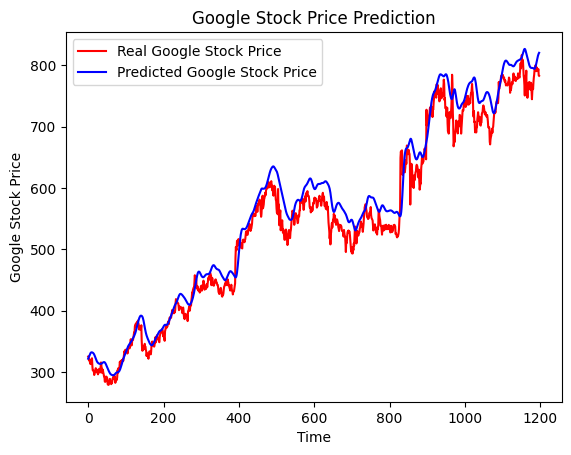

In [39]:
plt.plot(real_stock_price,
         color='red',
         label='Real Google Stock Price')

plt.plot(predicted_stock_price,
         color='blue',
         label='Predicted Google Stock Price')

plt.title('Google Stock Price Prediction')

plt.xlabel('Time')

plt.ylabel('Google Stock Price')

plt.legend()

plt.show()